In [61]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tahirmohd/network-ad/Social_Network_Ads.csv


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
df=pd.read_csv('/kaggle/input/datasets/tahirmohd/network-ad/Social_Network_Ads.csv')

In [64]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [65]:
df.rename(columns={'EstimatedSalary':'sal'})

,Age,sal,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [66]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

## Train Test Split

In [67]:
from sklearn.model_selection import train_test_split


x_train,x_test,y_train,y_test = train_test_split(df.drop('Purchased',axis=1),df['Purchased'],test_size=0.2,random_state=0)
x_train.shape
x_test.shape

(80, 2)

## ****Standard Scaler****

In [68]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

# Fit only on the Train data
scaler.fit(x_train)

# Transform on train and Test Data
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [69]:
x_train_scaled

array([[ 1.92295008e+00,  2.14601566e+00],
       [ 2.02016082e+00,  3.78719297e-01],
       [-1.38221530e+00, -4.32498705e-01],
       [-1.18779381e+00, -1.01194013e+00],
       [ 1.92295008e+00, -9.25023920e-01],
       [ 3.67578135e-01,  2.91803083e-01],
       [ 1.73156642e-01,  1.46942725e-01],
       [ 2.02016082e+00,  1.74040666e+00],
       [ 7.56421121e-01, -8.38107706e-01],
       [ 2.70367388e-01, -2.87638347e-01],
       [ 3.67578135e-01, -1.71750061e-01],
       [-1.18475597e-01,  2.20395980e+00],
       [-1.47942605e+00, -6.35303205e-01],
       [-1.28500455e+00, -1.06988428e+00],
       [-1.38221530e+00,  4.07691369e-01],
       [-1.09058306e+00,  7.55356227e-01],
       [-1.47942605e+00, -2.00722133e-01],
       [ 9.50842613e-01, -1.06988428e+00],
       [ 9.50842613e-01,  5.81523798e-01],
       [ 3.67578135e-01,  9.87132798e-01],
       [ 5.61999628e-01, -8.96051849e-01],
       [-6.04529329e-01,  1.45068594e+00],
       [-2.12648508e-02, -5.77359062e-01],
       [-6.

In [70]:
## Converting it into dataframe

x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_train.columns)

In [71]:
x_train_scaled.head()

,Age,EstimatedSalary
0,1.922950,2.146016
1,2.020161,0.378719
2,-1.382215,-0.432499
3,-1.187794,-1.011940
4,1.922950,-0.925024


In [72]:
x_train.describe()

,Age,EstimatedSalary
count,320.00000,320.000000
mean,38.21875,69928.125000
std,10.30304,34570.057299
min,18.00000,15000.000000
25%,30.00000,43000.000000
50%,38.00000,69500.000000
75%,46.00000,88000.000000
max,60.00000,150000.000000


In [73]:
x_train_scaled.describe()

,Age,EstimatedSalary
count,320.000000,3.200000e+02
mean,0.000000,1.110223e-17
std,1.001566,1.001566e+00
min,-1.965480,-1.591382e+00
25%,-0.798951,-7.801636e-01
50%,-0.021265,-1.240367e-02
75%,0.756421,5.235797e-01
max,2.117372,2.319848e+00


## Effects of Scalling

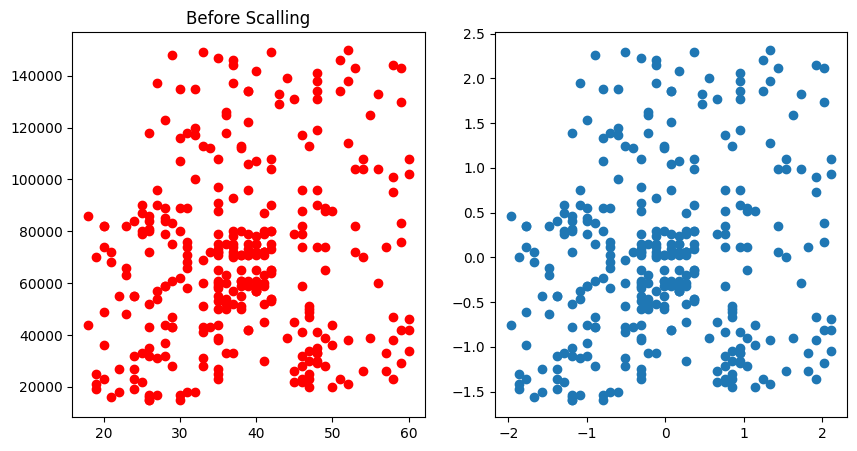

In [90]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(x=x_train['Age'],y=x_train['EstimatedSalary'],color='red')
plt.title('Before Scalling')


plt.subplot(1,2,2)
plt.scatter(x=x_train_scaled['Age'],y=x_train_scaled['EstimatedSalary'])
plt.show()
plt.show('After Scaling')

Text(0.5, 1.0, 'Age After Scaling')

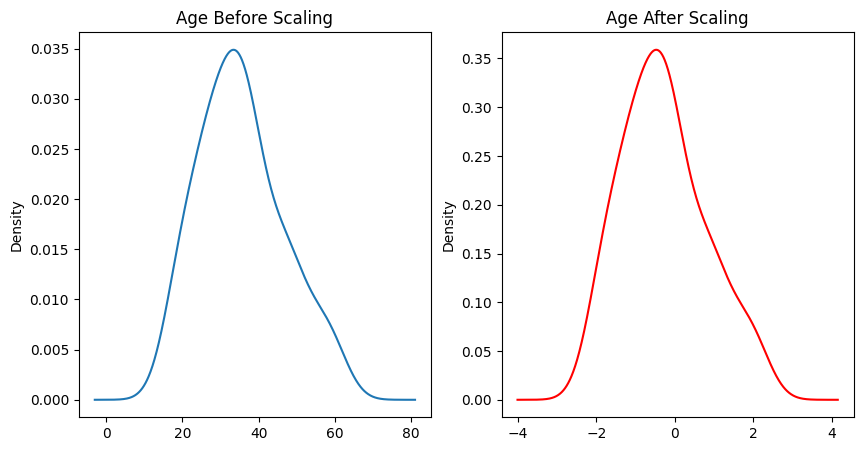

In [97]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
x_test['Age'].plot(kind='kde')
plt.title("Age Before Scaling")

plt.subplot(1,2,2)
x_test_scaled['Age'].plot(kind='kde',color='red')
plt.title("Age After Scaling")

<Axes: xlabel='Age', ylabel='Density'>

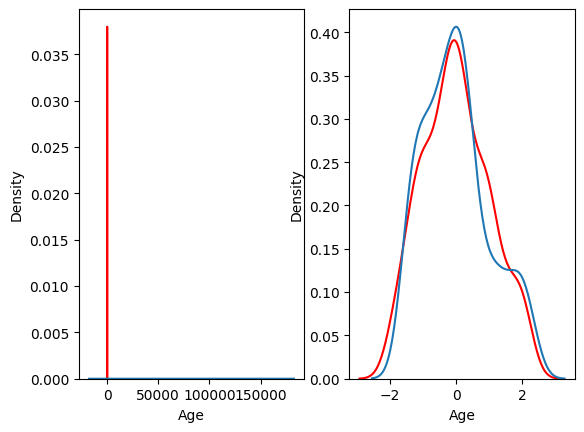

In [104]:
plt.subplot(1,2,1)

sns.kdeplot(x_train['Age'],color='red')
sns.kdeplot(x_train['EstimatedSalary'])

plt.subplot(1,2,2)

sns.kdeplot(x_train_scaled['Age'],color='red')
sns.kdeplot(x_train_scaled['EstimatedSalary'])

In [110]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()
lr_scaled=LogisticRegression()

# Train Model
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)



LogisticRegression()

In [112]:
y_pred=lr.predict(x_test)
y_pred_scaled=lr_scaled.predict(x_test_scaled)

In [116]:
from sklearn.metrics import accuracy_score

print('Actual :',accuracy_score(y_test, y_pred))
print('After Standarization :',accuracy_score(y_test, y_pred_scaled))

Actual : 0.9125
After Standarization : 0.925


In [ ]:
# See The difference in the result after and before standarization